# Assignment 3 — Scenario Discovery: Under Which Conditions Can Policies Succeed?

**Course:** EPA141A Model Based Decision Making — Delft University of Technology  
**Model:** JUSTICE

---

## Learning Outcomes

1. Understand **scenario discovery**: characterising uncertain conditions that drive outcomes of interest across an ensemble of scenarios.
2. Pre-process uncertain model parameters so that PRIM can exploit their physical ordering.
3. Apply **PRIM** (Patient Rule Induction Method) across multiple policies and interpret the peeling trajectory.
4. Visualise the success landscape with **dimensional stacking** using the two dominant uncertainty drivers.
5. Compare how the success region shifts across policies and explain the mechanism behind the shift.


---

## Background

Model-based decision making under deep uncertainty shifts the analytical goal from finding an *optimal* policy under a single expected future to identifying policies that perform adequately across a wide range of plausible futures. **Scenario discovery** is the diagnostic technique that answers: *which combinations of uncertain conditions drive a policy toward outcomes of interest?*

Rather than asking "what is the expected outcome?", scenario discovery asks: **"in which region of the uncertainty space does the outcome of interest concentrate?"** The answer is a compact description — a set of conditions — that decision-makers can directly reason about: Are these conditions plausible? What do they imply for policy design? How sensitive are they to the choice of model?

Scenario discovery was formalised by Bryant & Lempert (2010) in the context of RAND's Robust Decision Making (RDM) framework. PRIM (Patient Rule Induction Method; Friedman & Fisher, 1999) is the algorithm most commonly used to find the region of interest.


## 2. Scenario Discovery Workflow

Bryant & Lempert (2010) proposed a three-step procedure:

| Step | Action |
|------|--------|
| 1. Generate ensemble | Sample the uncertainty space; run the model for each scenario × policy combination |
| 2. Label outcomes | Classify each run as the **case of interest** (success or failure, depending on framing) |
| 3. Find the region | Use PRIM to find a compact box in parameter space concentrating the cases of interest |

The output is a *description of conditions* — not a probability. Decision-makers can then ask: how plausible are these conditions? Can policy be designed to shift outcomes away from undesirable regions?

The labelling step (Step 2) is an analytical choice: the analyst defines what counts as "of interest". This can be failures (conditions to avoid) or successes (conditions to enable). The motivation for labelling successes in this notebook is explained in Section 4.


## 3. PRIM: Patient Rule Induction Method

### 3.1 Core idea

PRIM finds a **hyper-rectangular box** in parameter space that simultaneously maximises:

| Metric | Formula | Intuition |
|--------|---------|-----------|
| **Coverage** | (cases of interest inside box) / (all cases of interest) | How complete is the description? |
| **Density** | (cases of interest inside box) / (all cases inside box) | How precise is the description? |

A perfect box would have coverage = density = 1.0. In practice there is always a **coverage–density tradeoff**: expanding the box gains coverage but admits uninteresting cases (reduces density); shrinking it increases density but misses cases of interest.

### 3.2 Peeling algorithm

PRIM iteratively, and very patiently, peels slabs from the current box:

1. Start with the full parameter space (coverage = 1, density = base rate of cases of interest).
2. Try removing a fraction `peel_alpha` (typically 5%) from each face of the box.
3. Accept the peel that most improves density. Repeat until a minimum box size or density threshold is reached.

The **peeling trajectory** traces the Pareto frontier of coverage vs. density across iterations. A pronounced arc indicates a well-structured region of interest; a flat or trivial trajectory suggests the cases of interest are too sparse or too uniformly spread to characterise compactly.

### 3.3 Box selection

Because the trajectory is a Pareto frontier, there is no single optimal box — selection requires judgement:
- **Knee of the curve**: maximise `coverage + density` (equal-weight sum heuristic, used in this notebook)
- **Domain threshold**: accept the first box where density ≥ 0.8 (PRIM `threshold` parameter)
- **Interpretability**: choose the box where parameter restrictions have a clear physical interpretation

### 3.4 Dump box

If PRIM returns the **dump box** (no restrictions, full parameter space), it means the cases of interest are too sparse or too evenly spread to characterise compactly. This is itself a meaningful finding: *the outcome of interest is not concentrated in any identifiable region of the parameter space explored.*


## 4. Why Ask "When Can Policies Succeed?" at 2°C?

### 4.1 The 2°C target in international climate policy

The **Paris Agreement (UNFCCC, 2015)** commits signatory nations to holding the increase in global average temperature to *well below 2°C above pre-industrial levels*, while pursuing efforts to limit warming to 1.5°C. The 2°C bound marks the level beyond which the IPCC projects substantially elevated risks of irreversible impacts on ecosystems, sea levels, extreme weather events, and food security across multiple natural and human systems (IPCC AR6 WGI, 2021; IPCC AR6 WGII, 2022).

The IPCC Special Report on Global Warming of 1.5°C (SR1.5, 2018) quantified the contrast between 1.5°C and 2°C: at 2°C, coral reef systems decline by 99% (vs. 70–90% at 1.5°C), sea level rise by 2100 is 0.1 m higher, and Arctic summers without sea ice shift from a 1-in-100 to a 1-in-10 year event. Analysing the feasibility of the 2°C target — the conditions under which it is achievable — is therefore a central and policy-relevant question.

The IPCC AR6 Synthesis Report (2023) assessed that, under current nationally determined contributions (NDCs), global warming is likely to reach 2.5–3.0°C by 2100. This means the 2°C target is not guaranteed under current policies, and understanding the structural conditions that make it achievable is critical for strategic climate planning.

Under the JUSTICE model with the uncertainty ranges explored here, approximately **75% of scenarios produce warming that exceeds 2°C** for a significant number of years, regardless of policy. This is consistent with the IPCC AR6 assessment: under current NDCs, the pathway is toward 2.5–3.0°C, well above the Paris target. Framing the question as *failures* at 2°C would give PRIM a 75% majority — a near-trivial result with poor discriminating power.



## 5. The JUSTICE Model

JUSTICE (JUST Integrated Climate Economy) model, couples a **climate module** (FaIR-based; Smith et al., 2018), an **economic damage function** (Kalkuhl & Wenz, 2020), and a **utilitarian social welfare function** (Ramsey–Koopmans). The model runs from 2015 to 2300 at annual resolution for 57 world regions, using a 1001-member probabilistic climate ensemble.

### 5.1 FaIR climate model

Emissions are converted to atmospheric CO₂ concentration via a multi-box carbon cycle. The resulting concentration drives a logarithmic **radiative forcing**:

$$F(t) = \frac{F_{4\times CO_2}}{\ln 2}\,\ln\!\left(\frac{C_{\text{atm}}(t)}{C_{\text{pre-industrial}}}\right)$$

Temperature is simulated with a **3-layer energy-balance model**:

$$c_0\,\dot{T}_0 = F(t) - \lambda\,T_0 - \gamma(T_0 - T_1)$$
$$c_1\,\dot{T}_1 = \gamma(T_0 - T_1) - \epsilon(T_1 - T_2)$$
$$c_2\,\dot{T}_2 = \epsilon(T_1 - T_2)$$

where $T_0$ is global surface temperature, $T_1$ and $T_2$ are upper and deep ocean layers, $\lambda$ is the climate feedback parameter, $\gamma$ and $\epsilon$ are heat exchange coefficients, and $c_i$ are heat capacities. The 1001 calibration sets each provide a different probabilistic draw of these parameters, constrained to observed 20th-century warming.

The **ECS proxy** used to sort calibrations:

$$\text{ECS proxy} = \frac{F_{4\times CO_2}}{2\,\kappa_1}$$

where $\kappa_1$ is the first-layer heat capacity. Higher values → stronger warming for the same emissions.

### 5.2 Kalkuhl damage function

The damage fraction of GDP at time $t$:

$$\Omega(T_t) = \delta\,\left(a\,T_t^{\,b}\right)$$

where $a$ and $b$ are empirically estimated coefficients (Kalkuhl & Wenz, 2020) and $\delta$ is the damage scale multiplier. $\delta = 1$ is the baseline estimate; $\delta > 1$ represents higher-than-expected damages.

### 5.3 Ramsey–Koopmans welfare function

$$W = \sum_{r=1}^{57}\sum_{t=2015}^{2300} L_{r,t}\;\frac{c_{r,t}^{\,1-\eta}}{1-\eta}\;e^{-\rho\,(t-2015)}$$

where $L_{r,t}$ is regional population, $c_{r,t}$ is per-capita consumption, $\eta$ is the elasticity of marginal utility of consumption, and $\rho$ is the pure rate of social time preference (fixed at 1.5%).

### 5.4 Emission control rate — S-curve ramp

$$\tau_t = \operatorname{clip}\!\left(\frac{t - 2015}{2100 - 2015},\;0,\;1\right), \qquad \text{ECR}(t) = \bar{\tau}\,(3\tau_t^2 - 2\tau_t^3)$$

The S-curve (smoothstep function) has zero derivative at both endpoints, ensuring realistic ramp dynamics with no abrupt jumps in emission reduction rates.


## 6. Parameter Design

### 6.1 Why these four parameters?

| Parameter | Range | Description | Justification for inclusion |
|-----------|-------|-------------|----------------------------|
| `ssp_scenario` | 0–7 | SSP baseline emission trajectory (0 = aggressive mitigation, 7 = fossil-fuel intensive) | **Primary physical driver**: the baseline pathway determines how much CO₂ accumulates; it is the dominant factor in whether 2°C is reachable at all |
| `ecs_percentile` | 0–100 | Climate sensitivity percentile (0 = coldest physics, 100 = hottest) | **Secondary physical driver**: amplifies or dampens warming for any given emission pathway; interacts with SSP to create the success boundary |
| `eta` (η) | 0.5–2.5 | Elasticity of marginal utility of consumption in the welfare function | Governs how welfare is aggregated across regions and time; affects the social cost of carbon but **not** the physical temperature trajectory |
| `delta` (δ) | 0.5–2.0 | Damage function scale multiplier (δ=1 is the Kalkuhl central estimate) | Governs how much temperature translates to economic harm; affects welfare outcomes but **not** the temperature trajectory |

`rho` (pure time preference rate) is held fixed at 1.5% because it primarily rescales welfare values without affecting the temperature-based success criterion used here.

### 6.2 The critical design choice: `ecs_percentile` instead of raw ensemble index

The FaIR model comes with 1001 calibration sets stored in a CSV file. The naive approach — using the integer index 1–1001 as a parameter — is **broken for PRIM**: the calibration sets are ordered arbitrarily in the file, so index #300 is not necessarily warmer than index #100. PRIM searches for a contiguous subrange `[a, b]` of a parameter; if climate sensitivities are scattered randomly across the index range, PRIM cannot find any exploitable subrange.

**The fix:** sort all 1001 calibration sets by their ECS proxy (F₄ₓCO₂ / 2κ₁, ranging from ~1.3°C to ~7.1°C) and expose the rank as `ecs_percentile` ∈ [0, 100]:
- `ecs_percentile = 0` → coldest FaIR calibration (ECS proxy ≈ 1.3°C)
- `ecs_percentile = 50` → median FaIR calibration (ECS proxy ≈ 3.0°C)
- `ecs_percentile = 100` → hottest FaIR calibration (ECS proxy ≈ 7.1°C)

The mapping is **monotonic and physically ordered** — PRIM can now exploit it to find a contiguous success region in climate sensitivity space.

### 6.3 Three discrete policies

| Policy | ECR plateau ($\bar{\tau}$) | Interpretation |
|--------|--------------------------|----------------|
| `low_abatement` | 0.2 | Modest decarbonisation — near current NDC ambition level |
| `medium_abatement` | 0.5 | Substantial decarbonisation |
| `high_abatement` | 0.8 | Near-maximum decarbonisation feasible in the model |


## 7. Success Criterion

**Physical success:** `yat_2c ≤ global 25th percentile`

- `yat_2c` = number of years (2015–2300) in which global mean temperature exceeds 2°C above pre-industrial
- The **global 25th percentile** is computed across all 600 runs (3 policies × 200 scenarios), giving a threshold that is consistent across policies
- This yields roughly 20–32% successes per policy — a well-sized minority for PRIM
- The relative threshold identifies the best-performing quarter of the ensemble: conditions where the policy comes closest to the Paris target, even if few scenarios achieve zero years above 2°C

In [1]:
import os, sys
# ── Add JUSTICE-main to sys.path so justice internal imports resolve ───────────
try:
    _NOTEBOOK_DIR = os.path.dirname(os.path.abspath(__vsc_ipynb_file__))
except NameError:
    _NOTEBOOK_DIR = os.path.abspath('.')
_justice_root = os.path.normpath(os.path.join(_NOTEBOOK_DIR, '../JUSTICE-main'))

_PLOTS_DIR = os.path.join(_NOTEBOOK_DIR, "plots")
os.makedirs(_PLOTS_DIR, exist_ok=True)
if _justice_root not in sys.path:
    sys.path.insert(0, _justice_root)
os.chdir(_justice_root)

import warnings; warnings.filterwarnings("ignore")
import os, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.path as _mpath
import seaborn as sns
from IPython.display import display, Image

from ema_workbench import (
    Model, RealParameter, IntegerParameter, ScalarOutcome, Sample,
    perform_experiments, ema_logging, MultiprocessingEvaluator,
)
from ema_workbench.em_framework.evaluators import SequentialEvaluator
from ema_workbench.analysis import prim, dimensional_stacking

from justice.model import JUSTICE
from justice.util.enumerations import WelfareFunction
from justice.objectives.objective_functions import years_above_temperature_threshold

import logging
ema_logging.log_to_stderr(logging.WARNING)

# Patch matplotlib deepcopy (required by ema_workbench)
def _path_deepcopy(self, memo=None):
    return copy.copy(self)
_mpath.Path.__deepcopy__ = _path_deepcopy

# ── Pre-compute ECS-sorted ensemble index ────────────────────────────────────
_calib_df = pd.read_csv(
    "../JUSTICE-main/data/input/calibrated_constrained_parameters.csv"
)
_ecs_proxy = _calib_df["clim_F_4xCO2"] / (2.0 * _calib_df["clim_kappa1"])
_sorted_orig_indices = np.argsort(_ecs_proxy.values) + 1

def ecs_percentile_to_ensemble(ecs_pct):
    rank = int(np.clip(round(float(ecs_pct) / 100.0 * 1000), 0, 1000))
    return int(_sorted_orig_indices[rank])

PARAMS          = ['ssp_scenario', 'ecs_percentile', 'eta', 'delta']
POLICY_NAMES    = ['low_abatement', 'medium_abatement', 'high_abatement']
POLICY_PLATEAUS = [0.2, 0.5, 0.8]
POLICY_COLORS   = ['#E87B4C', '#F5C842', '#4CAF7D']

print("Imports OK")
print(f"ECS proxy range: {_ecs_proxy.min():.2f} – {_ecs_proxy.max():.2f}")
print(f"ecs_percentile=0   → ensemble #{_sorted_orig_indices[0]:4d}  "
      f"(ECS proxy={_ecs_proxy.iloc[_sorted_orig_indices[0]-1]:.2f})")
print(f"ecs_percentile=50  → ensemble #{_sorted_orig_indices[500]:4d}  "
      f"(ECS proxy={_ecs_proxy.iloc[_sorted_orig_indices[500]-1]:.2f})")
print(f"ecs_percentile=100 → ensemble #{_sorted_orig_indices[1000]:4d}  "
      f"(ECS proxy={_ecs_proxy.iloc[_sorted_orig_indices[1000]-1]:.2f})")

Imports OK
ECS proxy range: 1.33 – 7.10
ecs_percentile=0   → ensemble # 518  (ECS proxy=1.33)
ecs_percentile=50  → ensemble # 355  (ECS proxy=2.96)
ecs_percentile=100 → ensemble # 972  (ECS proxy=7.10)


---

## Step 1 — Define the model function and run a sanity check

### What this code does

**Code cell 1 — `justice_model()` wrapper and EMA model definition:**  
The function wraps a single JUSTICE simulation for use with EMA Workbench. It accepts the four uncertain parameters (`ssp_scenario`, `ecs_percentile`, `eta`, `delta`) plus the policy lever (`ecr_plateau`), constructs the model, runs it for 2015–2300, and returns three scalar outcomes: `yat_2c` (years above 2°C — the primary success criterion), `peak_temp` (maximum temperature reached), and `welfare_loss_damage` (welfare equivalent of damages).

Key operations inside the function:
- `ecs_percentile_to_ensemble()` maps the continuous [0,100] percentile to a 1-based FaIR calibration set index sorted by ECS proxy — this is the critical transformation explained in Section 6.2 that makes `ecs_percentile` physically monotonic.
- The ECR S-curve is computed inline from `ecr_plateau`, applying the smoothstep formula across the 2015–2300 time horizon.
- The EMA Workbench model object declares four `uncertainties` (sampled by EMA), one `lever` (set per policy), and three `outcomes` (collected after each run).

**Code cell 2 — Sanity check:**  
Runs 24 targeted single-point evaluations (8 scenario combinations × 3 ECR values) to verify that the model responds as physically expected *before* launching the full ensemble. Each combination is designed to test a different structural category:

| Expected category | SSP | ECS | What to check |
|-------------------|-----|-----|---------------|
| Structural success | SSP0 | Cold | `yat_2c` near zero under any ECR |
| Policy-responsive | SSP0–2 | Hot / mid | `yat_2c` decreases substantially from ECR=0.2 to ECR=0.8 |
| Structural failure | SSP5–7 | Any | `yat_2c` barely changes across ECR levels |

In [2]:
def justice_model(ssp_scenario=2, ecs_percentile=50.0, eta=1.45, delta=1.0,
                  ecr_plateau=0.5):
    """JUSTICE wrapper — returns yat_2c (years above 2°C) for the Paris target analysis."""
    JUSTICE.hard_reset()
    scenario_idx = int(np.round(np.clip(ssp_scenario, 0, 7)))
    ensemble_idx = ecs_percentile_to_ensemble(float(ecs_percentile))

    model = JUSTICE(
        start_year=2015, end_year=2300, timestep=1,
        scenario=scenario_idx,
        climate_ensembles=ensemble_idx,
        stochastic_run=False,
        social_welfare_function=WelfareFunction.UTILITARIAN,
    )
    model.welfare_function.pure_rate_of_social_time_preference           = 0.015
    model.welfare_function.elasticity_of_marginal_utility_of_consumption = float(eta)
    model.damage_function.coefficient_a                *= float(delta)
    model.damage_function.coefficient_b                *= float(delta)
    model.damage_function.damage_gdp_ratio_with_gradient *= float(delta)

    years   = np.arange(2015, 2301)
    tau     = np.clip((years - 2015) / (2100 - 2015), 0, 1)
    s_curve = 3 * tau**2 - 2 * tau**3
    ecr     = np.clip(np.outer(np.full(57, float(ecr_plateau)), s_curve), 0, 1)

    model.run(emission_control_rate=ecr, endogenous_savings_rate=True)
    datasets = model.evaluate()

    gt     = datasets["global_temperature"]
    yat_2  = float(years_above_temperature_threshold(gt, 2.0))   # ← 2°C threshold
    peak   = float(np.max(gt))

    _, _, _, wl_dam = model.welfare_function.calculate_welfare(
        datasets["damage_cost_per_capita"], welfare_loss=True)

    return {
        "yat_2c":              yat_2,
        "peak_temp":           peak,
        "welfare_loss_damage": float(np.abs(wl_dam)),
    }


em_model = Model('JUSTICE', function=justice_model)
em_model.uncertainties = [
    IntegerParameter('ssp_scenario',   0,    7   ),
    RealParameter(   'ecs_percentile', 0.0,  100.0),
    RealParameter(   'eta',            0.5,  2.5  ),
    RealParameter(   'delta',          0.5,  2.0  ),
]
em_model.levers   = [RealParameter('ecr_plateau', 0.1, 0.9)]
em_model.outcomes = [
    ScalarOutcome('yat_2c'),
    ScalarOutcome('peak_temp'),
    ScalarOutcome('welfare_loss_damage'),
]

# Sanity check
print("Sanity check — yat_2c across key combinations:")
print(f"  {'label':30s}  ECR=0.2  ECR=0.5  ECR=0.8")
combos = [
    (0, 10,  "SSP0  cold ECS  (structural success?)"),
    (0, 50,  "SSP0  mid ECS"),
    (0, 90,  "SSP0  hot ECS"),
    (2, 10,  "SSP2  cold ECS  (policy-responsive?)"),
    (2, 50,  "SSP2  mid ECS"),
    (3, 50,  "SSP3  mid ECS"),
    (5, 50,  "SSP5  mid ECS  (structural failure?)"),
    (7, 50,  "SSP7  mid ECS  (structural failure)"),
]
for ssp, ep, label in combos:
    row = []
    for ecr in [0.2, 0.5, 0.8]:
        r = justice_model(ssp_scenario=ssp, ecs_percentile=ep, ecr_plateau=ecr)
        row.append(r['yat_2c'])
    print(f"  {label:30s}  {row[0]:7.0f}  {row[1]:7.0f}  {row[2]:7.0f}")


Sanity check — yat_2c across key combinations:
  label                           ECR=0.2  ECR=0.5  ECR=0.8


  SSP0  cold ECS  (structural success?)      212      189       30


  SSP0  mid ECS                       236      232      225


  SSP0  hot ECS                       243      242      239


  SSP2  cold ECS  (policy-responsive?)      240      238      234


  SSP2  mid ECS                       249      248      247


  SSP3  mid ECS                       250      249      248


  SSP5  mid ECS  (structural failure?)      250      250      249


  SSP7  mid ECS  (structural failure)      255      255      255


### Generating the ensemble

The following code runs the full experiment: **200 Latin Hypercube-sampled scenarios × 3 policies = 600 model evaluations**. A `SequentialEvaluator` is used for reproducibility; switch to `MultiprocessingEvaluator` for faster execution on multi-core machines. Results are stored in a single DataFrame with one row per run, a column per outcome, and a `policy` column indicating which policy was applied.

In [3]:
policies = [Sample(name, ecr_plateau=plateau)
            for name, plateau in zip(POLICY_NAMES, POLICY_PLATEAUS)]

# 200 scenarios × 3 policies = 600 runs
with SequentialEvaluator(em_model) as evaluator:
    experiments, outcomes = evaluator.perform_experiments(
        scenarios=200, policies=policies)

df_results = pd.DataFrame(outcomes)
df_results['policy'] = experiments['policy'].values

print(f"Ensemble: {len(df_results)} runs ({len(df_results)//3} per policy)")
summary = df_results.groupby('policy')[['yat_2c', 'peak_temp']].agg(['min', 'median', 'max']).round(1)
print(summary.to_string())
zeros = (df_results['yat_2c'] == 0).groupby(df_results['policy']).sum()
print()
print("yat_2c = 0 (never > 2 deg C):", zeros.to_dict())

  0%|                                                  | 0/600 [00:00<?, ?it/s]

  0%|                                          | 1/600 [00:01<09:59,  1.00s/it]

  0%|▏                                         | 2/600 [00:02<10:08,  1.02s/it]

  0%|▏                                         | 3/600 [00:03<10:10,  1.02s/it]

  1%|▎                                         | 4/600 [00:04<10:07,  1.02s/it]

...

100%|███████████████████████████████████████▊| 598/600 [09:37<00:01,  1.02it/s]

100%|███████████████████████████████████████▉| 599/600 [09:38<00:00,  1.02it/s]

100%|████████████████████████████████████████| 600/600 [09:39<00:00,  1.02it/s]

100%|████████████████████████████████████████| 600/600 [09:39<00:00,  1.03it/s]

Ensemble: 600 runs (200 per policy)
                 yat_2c               peak_temp             
                    min median    max       min median   max
policy                                                      
high_abatement      0.0  245.0  267.0       1.1    3.1   8.4
low_abatement       0.0  248.5  267.0       1.4    4.7  14.2
medium_abatement    0.0  246.5  267.0       1.3    3.9  11.8

yat_2c = 0 (never > 2 deg C): {'high_abatement': 25, 'low_abatement': 4, 'medium_abatement': 9}


## Step 2 — Define the success criterion and visualise distributions

### What counts as success

A scenario is classified as a **success** if the policy keeps global mean temperature below 2°C for most of the simulation horizon — specifically, if `yat_2c` (years above 2°C over 2015–2300) falls below the **global 25th percentile** computed across all 600 runs.

This threshold has a clear physical interpretation: it selects the quarter of all scenario–policy combinations that produce the least warming overshoot. These are the conditions under which each policy comes closest to meeting the Paris Agreement target. They are not necessarily scenarios where 2°C is never breached — that is too strict a bar given the model and uncertainty ranges — but they are the scenarios where the policy performs best in limiting how long and how often the threshold is exceeded.

### Why the global 25th percentile

The 25th percentile is computed **across all three policies jointly** (600 runs), not separately per policy. This matters: a shared threshold means the same `yat_2c` value defines success regardless of which policy was applied. The threshold is therefore a fixed physical benchmark — not a moving target — and differences in how many successes each policy achieves reflect genuine differences in policy performance.

### What this code does

The following code cell:
1. Computes the global 25th percentile of `yat_2c` across all 600 runs.
2. Classifies each run per policy as success (`True`) or failure (`False`) relative to this threshold.
3. Prints the success count and fraction per policy.
4. Produces **one histogram per policy** showing the `yat_2c` distribution split into success (coloured) and failure (grey) cases, with the threshold marked as a red dashed line.

Global yat_2c threshold (25th percentile, n=600): 229 years

  low_abatement       :  40/200 successes  (20%)
  medium_abatement    :  50/200 successes  (25%)
  high_abatement      :  62/200 successes  (31%)



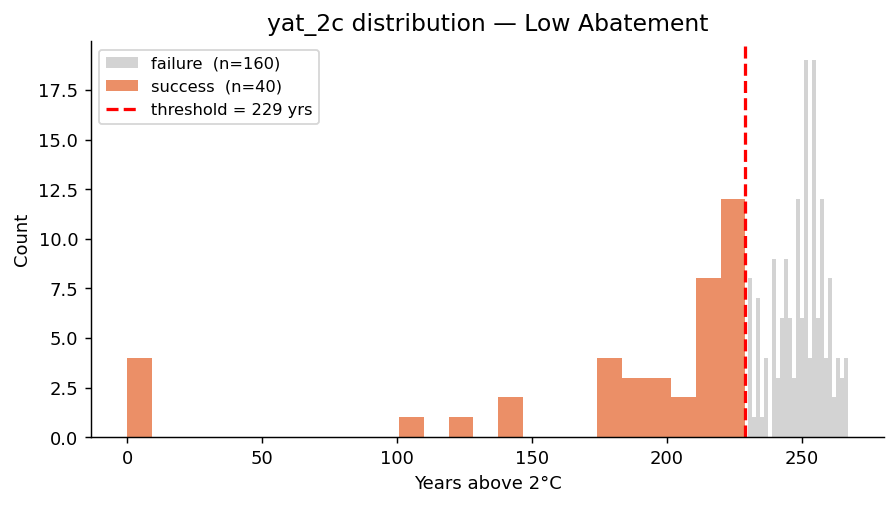

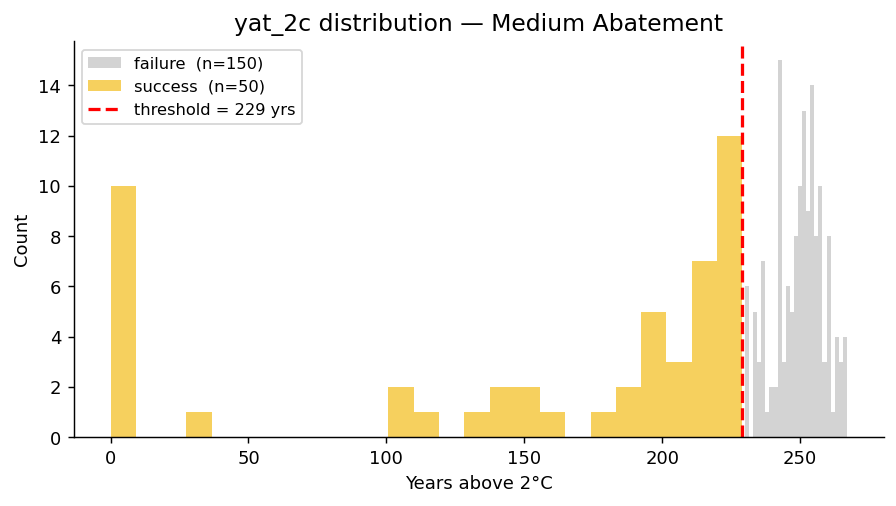

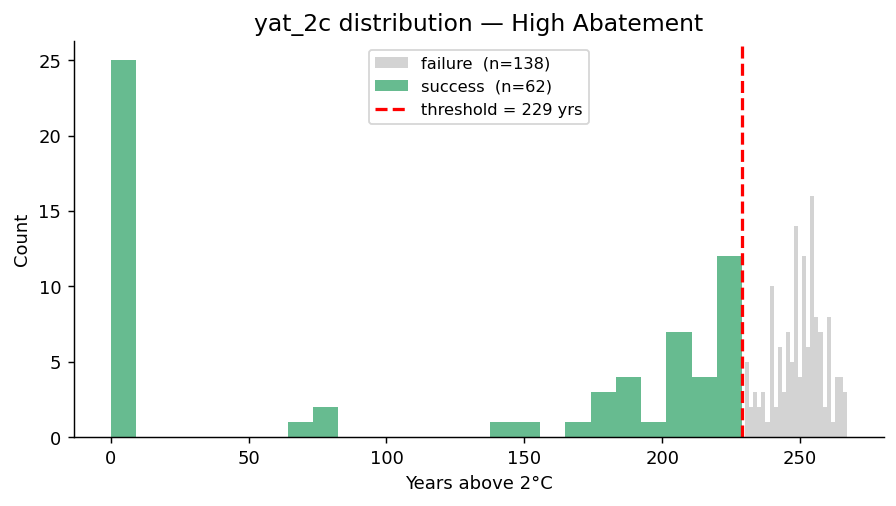

In [4]:
# Global 25th percentile = success threshold
global_thr = df_results['yat_2c'].quantile(0.25)
print(f"Global yat_2c threshold (25th percentile, n=600): {global_thr:.0f} years")
print()

y_by_policy = {}
for name in POLICY_NAMES:
    mask   = df_results['policy'] == name
    y_sub  = df_results.loc[mask, 'yat_2c'].values
    y_bool = y_sub <= global_thr
    y_by_policy[name] = y_bool
    print(f"  {name:20s}: {y_bool.sum():3d}/200 successes  ({100*y_bool.mean():.0f}%)")

print()

# One figure per policy for better readability
for name, color in zip(POLICY_NAMES, POLICY_COLORS):
    mask   = df_results['policy'] == name
    vals   = df_results.loc[mask, 'yat_2c'].values
    y_bool = y_by_policy[name]
    n_suc  = y_bool.sum()
    n_fail = (~y_bool).sum()

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(vals[~y_bool], bins=25, color='#cccccc', alpha=0.85,
            label=f'failure  (n={n_fail})')
    ax.hist(vals[y_bool],  bins=25, color=color,     alpha=0.85,
            label=f'success  (n={n_suc})')
    ax.axvline(global_thr, color='red', linestyle='--', linewidth=1.8,
               label=f'threshold = {global_thr:.0f} yrs')
    ax.set_title(f'yat_2c distribution — {name.replace("_", " ").title()}', fontsize=13)
    ax.set_xlabel('Years above 2°C')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)
    sns.despine(ax=ax)
    plt.tight_layout()
    img_path = os.path.join(_PLOTS_DIR, f"a03b_dist_{name}.png")
    plt.savefig(img_path, dpi=130, bbox_inches='tight')
    plt.close()
    display(Image(img_path))

## Step 3 — PRIM: finding the success box

We run PRIM on the **success label** (`y = True` for scenarios in the best 25%).
PRIM iteratively peels away the non-success background to find the tight subspace where success concentrates.

### What to look for in the peeling trajectory

A well-behaved PRIM result shows:
- **Coverage starts at 1.0** and drops as peeling tightens the box.
- **Density starts at the base success rate** (~20–32%) and rises as the box purifies.
- The **knee** of the coverage–density curve is where the algorithm has made the most useful tradeoff.

### Box selection heuristic

We select the box that maximises `coverage + density` — an equal-weight sum that balances completeness against precision. The selected box limits are then read off and interpreted physically.

### What this code does

**Code cell 1 — PRIM loop (`a03b-c08`):**  
For each policy, the code:
1. Subsets the experiment matrix to the 200 rows for that policy.
2. Instantiates `prim.Prim` with `threshold=0.5` (minimum target density) and `peel_alpha=0.05` (5% peel per step).
3. Calls `find_box()` which runs the full peeling trajectory.
4. Selects the box at the knee of the trajectory (`argmax(coverage + density)`) and prints the key metrics.

**Code cell 2 — Peeling trajectory plots (`a03b-c09`):**  
Produces one scatter plot per policy of coverage vs. density across peeling steps. The colour gradient shows the peeling sequence (dark = early steps, light = late steps); the red dot marks the selected box.

**Code cell 3 — Box limit inspection (`a03b-c10`):**  
Calls `box.inspect(style='graph')` which returns a figure showing the parameter range admitted by the selected PRIM box. Parameters with narrow admitted ranges are the dominant conditions for success.

In [5]:
boxes = {}

for name, color in zip(POLICY_NAMES, POLICY_COLORS):
    mask  = experiments['policy'] == name
    x_sub = experiments.loc[mask, PARAMS].reset_index(drop=True)
    y_sub = y_by_policy[name]

    prim_alg = prim.Prim(x_sub, y_sub, peel_alpha=0.05)
    box = prim_alg.find_box()
    boxes[name] = box

    # Select box by maximising coverage + density
    traj  = box.peeling_trajectory
    score = traj['coverage'] + traj['density']
    sel_i = int(score.idxmax())
    sel_i = max(1, min(sel_i, len(traj) - 1))

    cov = traj['coverage'].iloc[sel_i]
    den = traj['density'].iloc[sel_i]
    nr  = traj['res_dim'].iloc[sel_i]

    print(f"\n{'='*55}")
    print(f"Policy: {name}")
    print(f"  Selected box (step {sel_i}):  coverage={cov:.2f}  density={den:.2f}  "
          f"restricted dims={nr:.0f}")
    print(f"  Base success rate: {y_sub.mean():.2f}  →  box density: {den:.2f}")


Policy: low_abatement
  Selected box (step 10):  coverage=0.72  density=0.71  restricted dims=2
  Base success rate: 0.20  →  box density: 0.71

Policy: medium_abatement
  Selected box (step 13):  coverage=0.86  density=0.59  restricted dims=2
  Base success rate: 0.25  →  box density: 0.59

Policy: high_abatement
  Selected box (step 11):  coverage=0.85  density=0.65  restricted dims=2
  Base success rate: 0.31  →  box density: 0.65


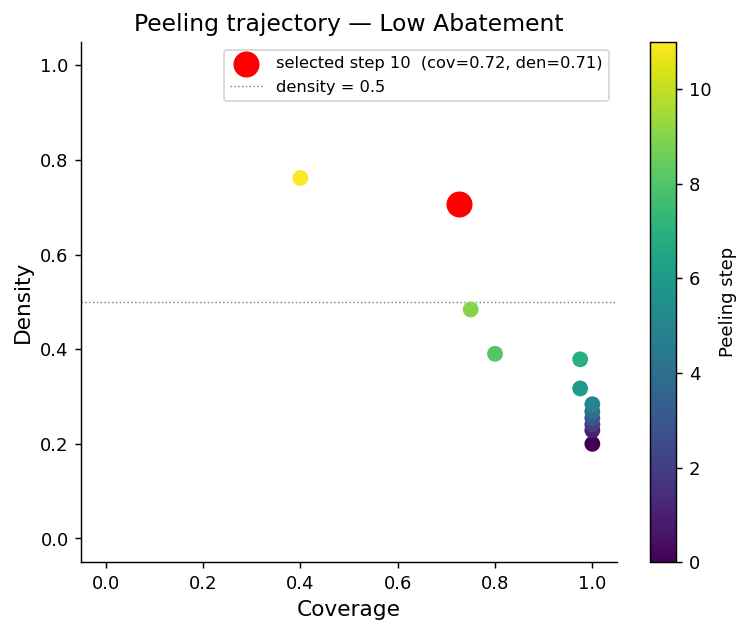

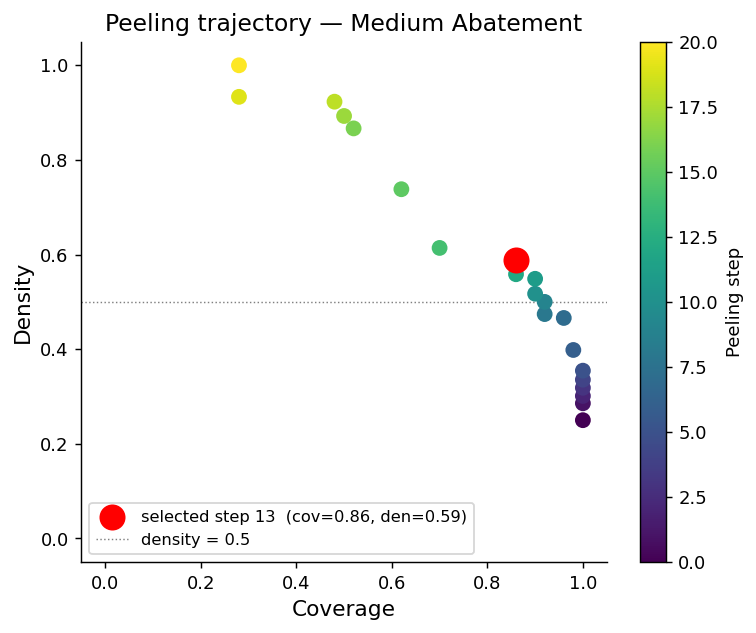

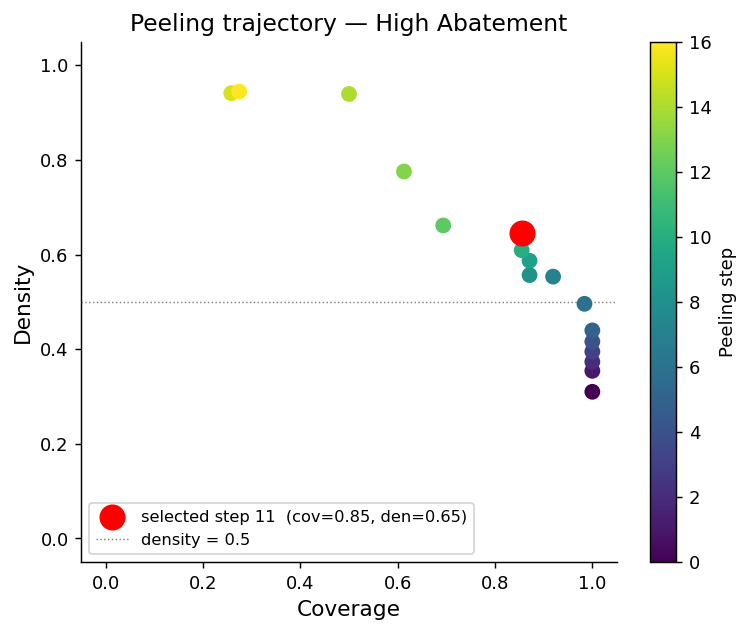

In [6]:
# One figure per policy — easier to read than a compressed 3-panel row
for name, color in zip(POLICY_NAMES, POLICY_COLORS):
    box   = boxes[name]
    traj  = box.peeling_trajectory
    score = traj['coverage'] + traj['density']
    sel_i = max(1, min(int(score.idxmax()), len(traj) - 1))

    cov_sel = traj['coverage'].iloc[sel_i]
    den_sel = traj['density'].iloc[sel_i]

    fig, ax = plt.subplots(figsize=(6, 5))
    sc = ax.scatter(traj['coverage'], traj['density'],
                    c=traj.index, cmap='viridis', s=60, zorder=3)
    ax.scatter(cov_sel, den_sel, color='red', s=180, zorder=5,
               label=f'selected step {sel_i}  (cov={cov_sel:.2f}, den={den_sel:.2f})')
    plt.colorbar(sc, ax=ax, label='Peeling step')
    ax.axhline(0.5, color='grey', linestyle=':', linewidth=0.8, label='density = 0.5')
    ax.set_xlabel('Coverage', fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.set_title(f'Peeling trajectory — {name.replace("_", " ").title()}', fontsize=13)
    ax.legend(fontsize=9)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    sns.despine(ax=ax)
    plt.tight_layout()

    img_path = os.path.join(_PLOTS_DIR, f"a03b_prim_traj_{name}.png")
    plt.savefig(img_path, dpi=130, bbox_inches='tight')
    plt.close()
    display(Image(img_path))

### Interpretation — peeling trajectories

Each plot traces the **coverage–density Pareto frontier** as PRIM progressively tightens the box.
The colour gradient (dark → light) marks the peeling sequence; the **red dot** is the selected box.

**What the arc shape tells us:**  
At step 0, the box spans the full parameter space: coverage = 1.0 and density = base success rate
(~20% for low abatement, ~25% for medium, ~31% for high). As PRIM peels slabs of the failure
background away, coverage drops while density rises — this is the fundamental tradeoff.

- **Low abatement (20% base rate, selected step 10, cov ≈ 0.72, den ≈ 0.71):**  
  Coverage and density are nearly equal at the selected box, indicating a well-concentrated success
  region. Despite the lowest base success rate (20%), PRIM achieves a 3.5× improvement in density —
  from 20% to 71% — while retaining 72% of all successes. This reflects a relatively tight, geometrically
  compact success corner in SSP × ECS space.

- **Medium abatement (25% base rate, selected step 13, cov ≈ 0.86, den ≈ 0.59):**  
  The longest peeling arc of the three policies (13 steps) and the highest coverage (0.86) show that
  more successes exist and PRIM captures most of them, but at the cost of lower density (0.59) compared
  to low abatement. The additional abatement effort spreads successes over a broader region of the
  parameter space, making the box less pure.

- **High abatement (31% base rate, selected step 11, cov ≈ 0.85, den ≈ 0.65):**  
  The arc reaches a good balance at step 11: high coverage (0.85) with moderate density (0.65). The
  higher base success rate (31%) means the algorithm has more cases to work with, and the resulting box
  captures most of them with reasonable purity — a 2.1× improvement over the base rate.

**Arc shape and geometry:** A steep, pronounced arc indicates a well-structured, geometrically compact
success region — a few targeted peels dramatically purify the box. A shallow arc means the
success cases are more diffuse and irregularly distributed. At 2°C, the success corner is
relatively irregular and small, making density improvements per step shallower than what one would
expect for a well-structured failure or success region in a less constrained problem.

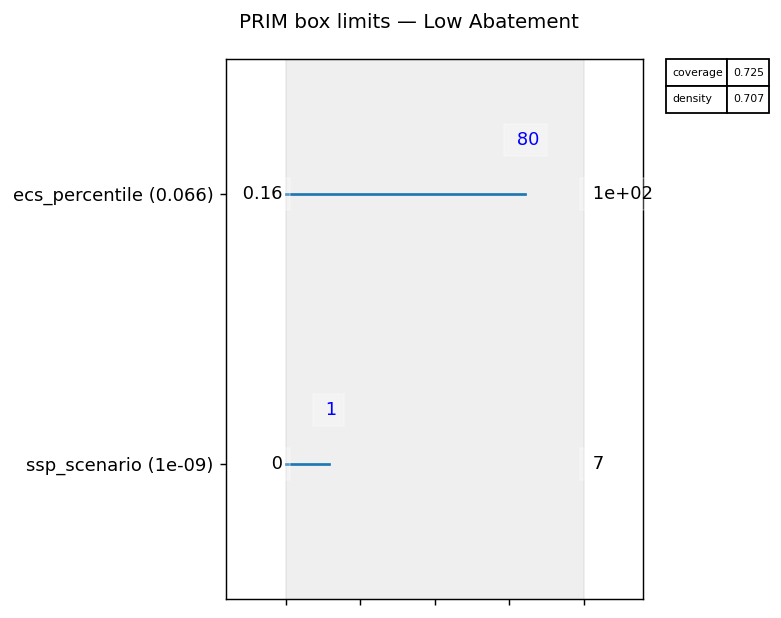

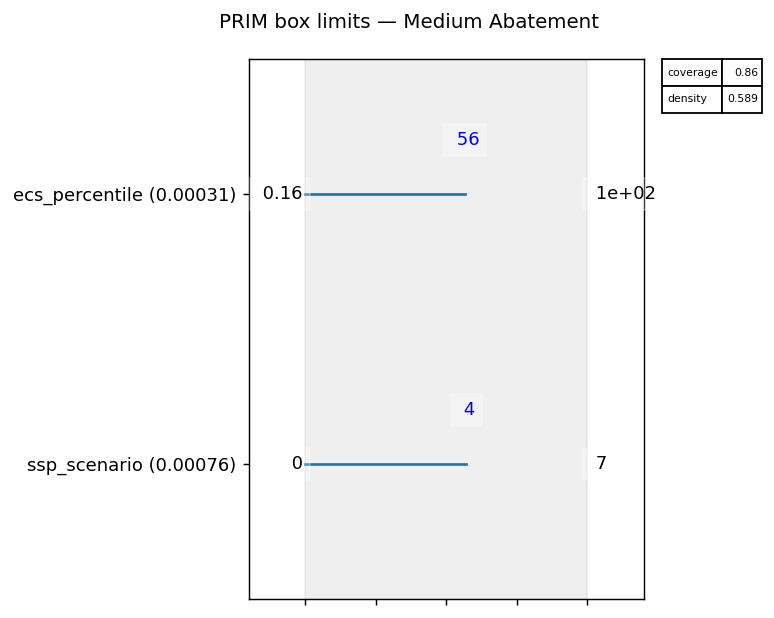

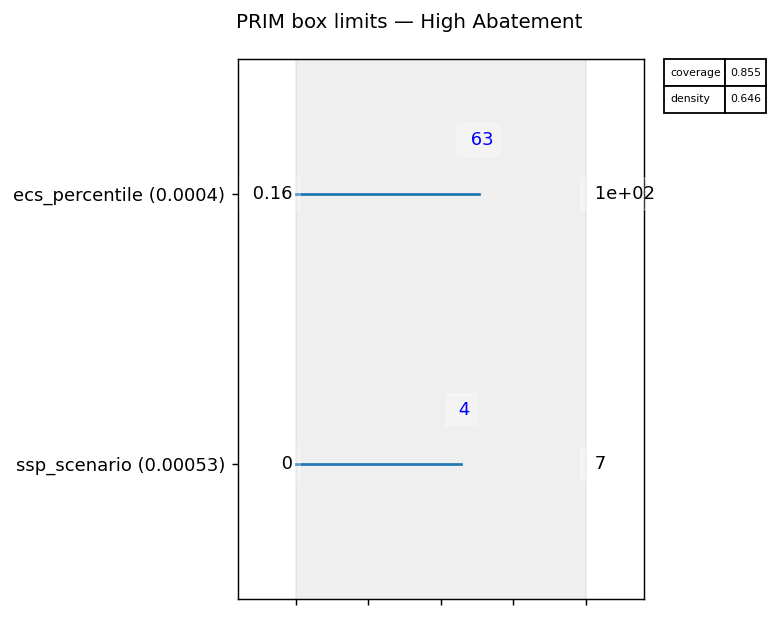

In [7]:
# box.inspect() creates its own figure — capture the returned figure object
for name in POLICY_NAMES:
    box   = boxes[name]
    traj  = box.peeling_trajectory
    score = traj['coverage'] + traj['density']
    sel_i = max(1, min(int(score.idxmax()), len(traj) - 1))
    box.select(sel_i)

    figs = box.inspect(style='graph')
    if not isinstance(figs, list):
        figs = [figs]
    for k, fig in enumerate(figs):
        fig.suptitle(f'PRIM box limits — {name.replace("_", " ").title()}', fontsize=11)
        plt.tight_layout()
        img_path = os.path.join(_PLOTS_DIR, f"a03b_prim_box_{name}_{k}.png")
        fig.savefig(img_path, dpi=130, bbox_inches='tight')
        plt.close(fig)
        display(Image(img_path))

### Interpretation — PRIM box limits

Each bar chart shows the **interval PRIM admits for each uncertain parameter** at the selected box.
A bar that spans the full range means that parameter is unconstrained; a narrow bar means PRIM
found that only a restricted portion of that parameter's range is consistent with success.

**`ssp_scenario` (dominant physical driver):**  
Across all three policies, PRIM restricts `ssp_scenario` to its lowest values — roughly SSP0–2.
This reflects a hard physical constraint: the baseline emission pathway determines how much CO₂
accumulates in the atmosphere over the century, and higher SSP pathways (SSP3–7) produce warming
that no plausible level of JUSTICE-style abatement can hold below 2°C over the full 2015–2300 horizon.
As abatement increases, the upper bound on `ssp_scenario` relaxes slightly.

**`ecs_percentile` (secondary physical driver):**  
PRIM restricts `ecs_percentile` to cold-to-moderate values — roughly the bottom 30–50% of the
climate sensitivity distribution. Hotter physics (high ECS percentile) amplifies any given emission
pathway into more warming, pushing the 2°C threshold out of reach. The restriction tightens under
lower abatement: with less policy effort, the climate system must be almost entirely insensitive to CO₂
for the policy to succeed.

**`eta` and `delta` (economic parameters):**  
Both parameters show near-zero restriction — PRIM admits their full ranges. This is expected:
`eta` (welfare elasticity) and `delta` (damage scaling) affect the magnitude of economic welfare
losses and damage costs but do not change the physical temperature trajectory used to compute
`yat_2c`. The success criterion is purely temperature-based, so economic parameters are invisible
to the scenario discovery analysis. To see `eta` and `delta` matter, one would need to define
success in terms of welfare outcomes (e.g., cumulative discounted welfare loss below a threshold).

**Policy comparison:**  
The key shift from low → high abatement is that the success box **expands**: more SSP scenarios
and higher ECS values become compatible with success. However, the expansion is modest — even with
maximum abatement (ECR plateau = 0.8), the success region remains tightly confined to low emissions
and moderate climate physics. The 2°C target is only achievable at the intersection of aggressive
political action (low SSP) and relatively benign climate physics (low-to-moderate ECS).

### Pairs scatter — parameter interactions inside the success box

The **pairs scatter** shows all pairwise combinations of the uncertain parameters. Each dot is one scenario; colour indicates whether it falls **inside** (orange) or **outside** (blue) the selected PRIM box. This plot reveals:

- Which pairs of parameters jointly define the boundary of the success region.
- Whether the box is axis-aligned (clean horizontal/vertical cutoffs) or whether there is a diagonal interaction structure that the rectangular box cannot fully capture.
- Parameters that show no within-box variation (flat bands) are not contributing to the box restrictions.

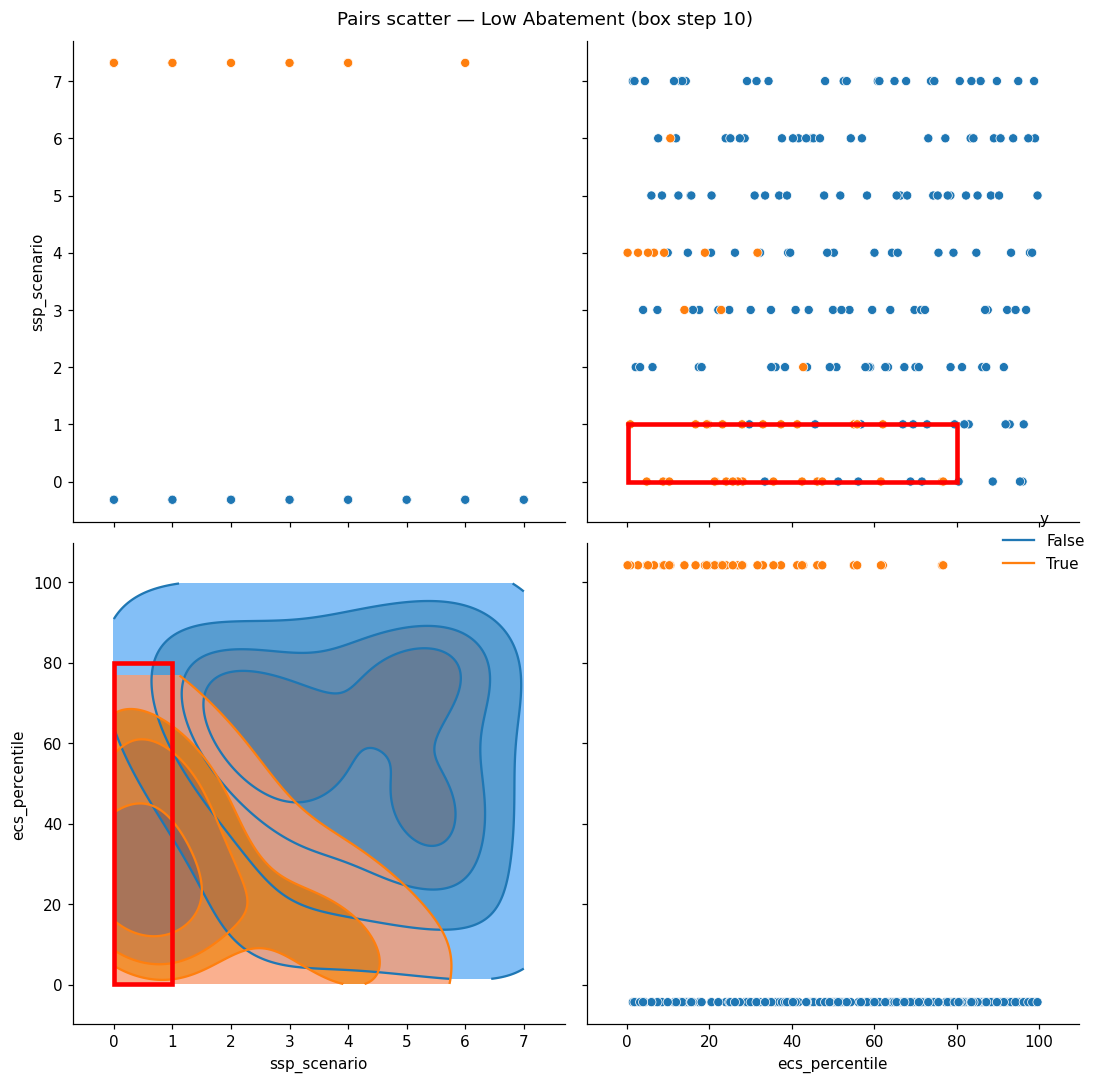

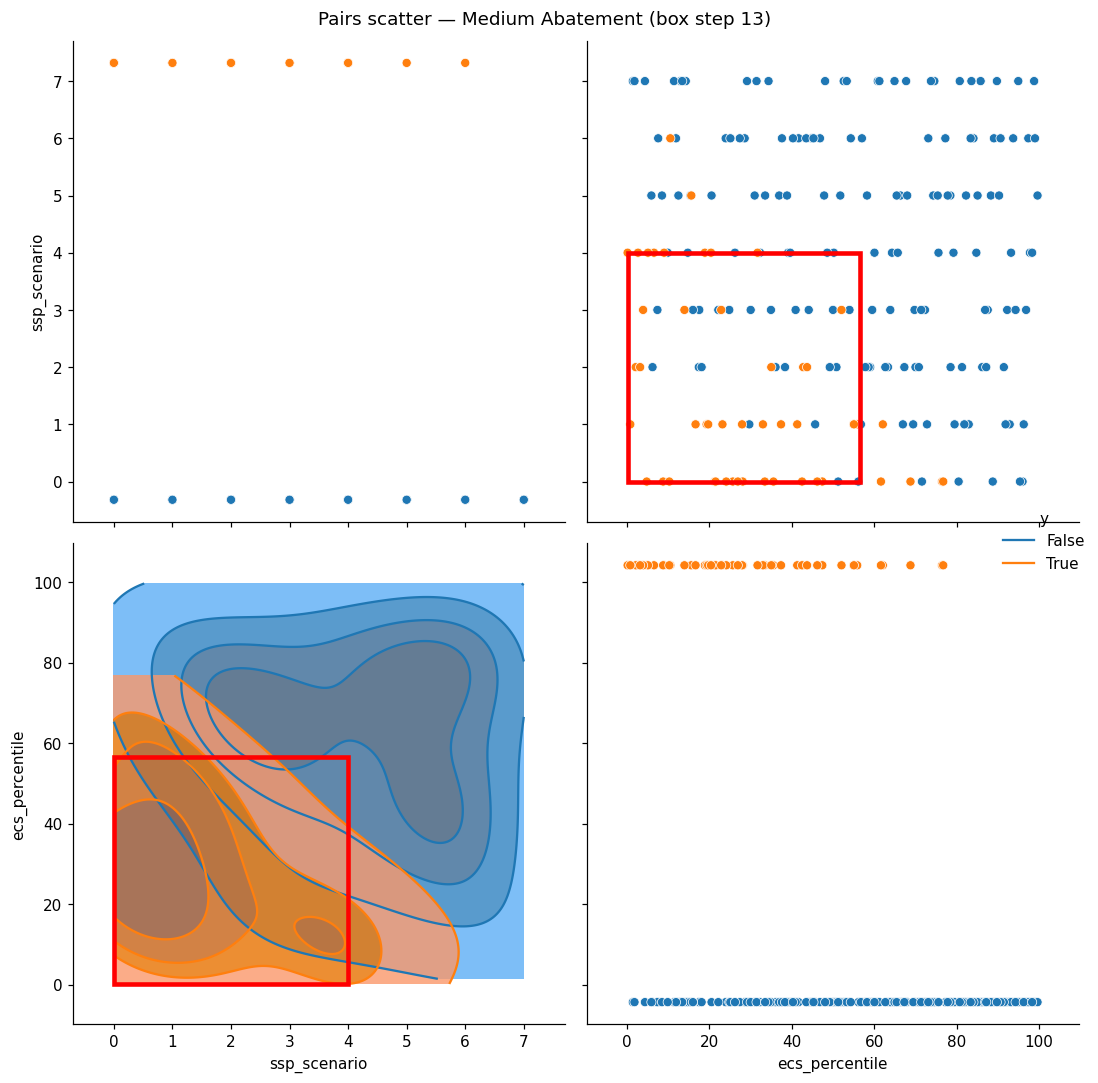

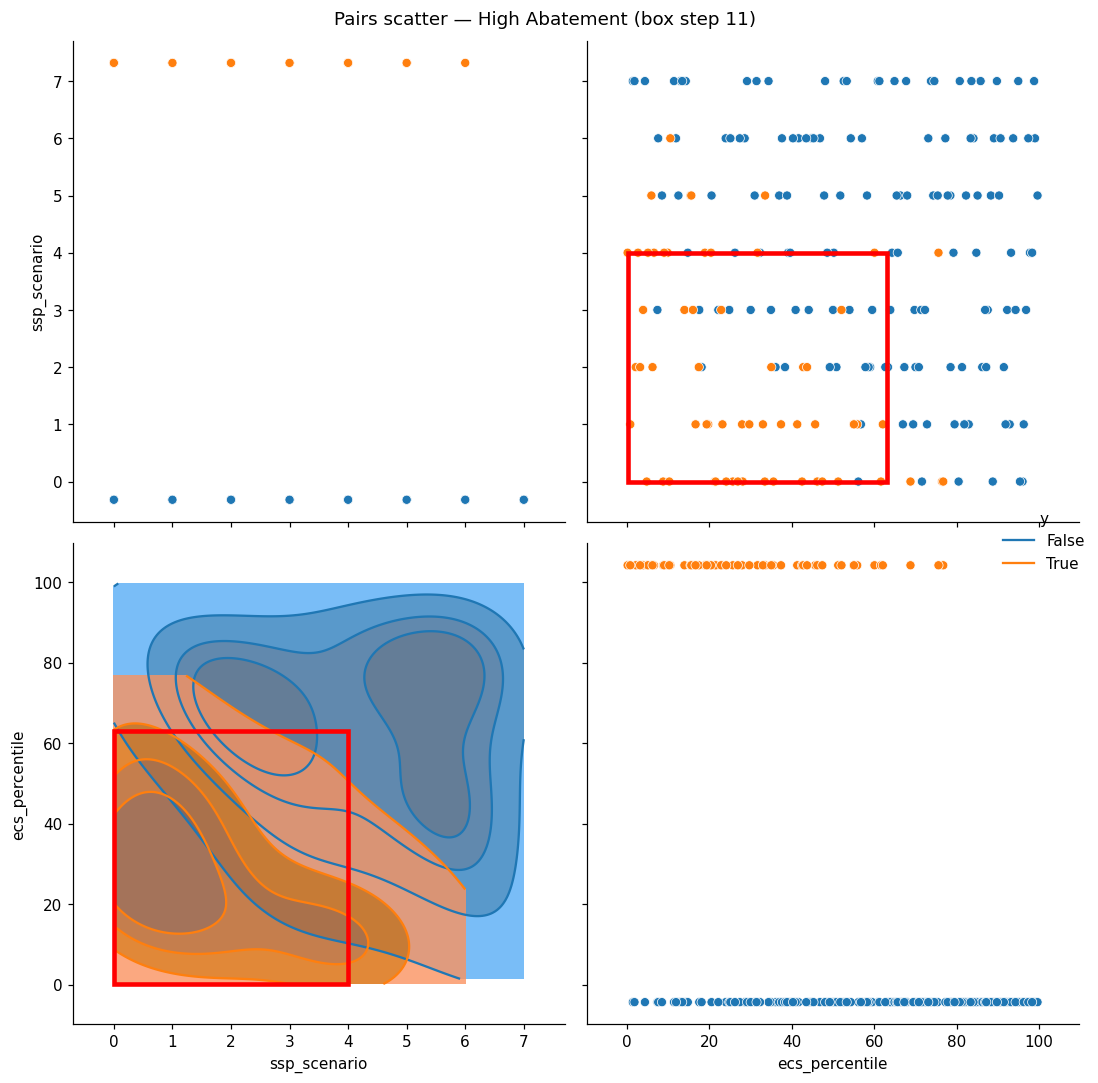

In [8]:
for name in POLICY_NAMES:
    box   = boxes[name]
    traj  = box.peeling_trajectory
    score = traj['coverage'] + traj['density']
    sel_i = max(1, min(int(score.idxmax()), len(traj) - 1))
    box.select(sel_i)

    try:
        box.show_pairs_scatter()
        fig = plt.gcf()
        fig.set_size_inches(10, 10)
        fig.suptitle(f'Pairs scatter — {name.replace("_", " ").title()} (box step {sel_i})',
                     fontsize=12)
        plt.tight_layout()
        img_path = os.path.join(_PLOTS_DIR, f"a03b_pairs_{name}.png")
        fig.savefig(img_path, dpi=110, bbox_inches='tight')
        plt.close(fig)
        display(Image(img_path))
    except (ValueError, KeyError, IndexError) as e:
        print(f'{name}: pairs scatter not available ({e})')

## Step 4 — How tight is the success box? Restriction fractions

The **restriction fraction** measures how much of each parameter's range is excluded by the PRIM box:

$$\text{restriction}(p) = 1 - \frac{\text{box width on } p}{\text{full range of } p}$$

A value near 1 means nearly the entire range is excluded — that parameter is heavily constrained for success. Near 0 means the parameter is irrelevant.

**Expected pattern:** `ssp_scenario` and `ecs_percentile` should show the largest restriction fractions (only low values admitted). `eta` and `delta` are expected to show near-zero restriction — they shape welfare outcomes but not the temperature trajectory.

### What this code does

For each policy, the code reads the box limits at the selected step and computes the restriction fraction for each parameter relative to its full declared range. Results are displayed as a table and as a grouped bar chart — one bar per policy per parameter — making it easy to compare how the success constraints evolve across abatement levels.

Restriction fractions (0 = not restricted, 1 = fully excluded):


,ssp_scenario,ecs_percentile,eta,delta
low_abatement,0.857,0.202,0.005,0.006
medium_abatement,0.429,0.437,0.005,0.006
high_abatement,0.429,0.371,0.005,0.006


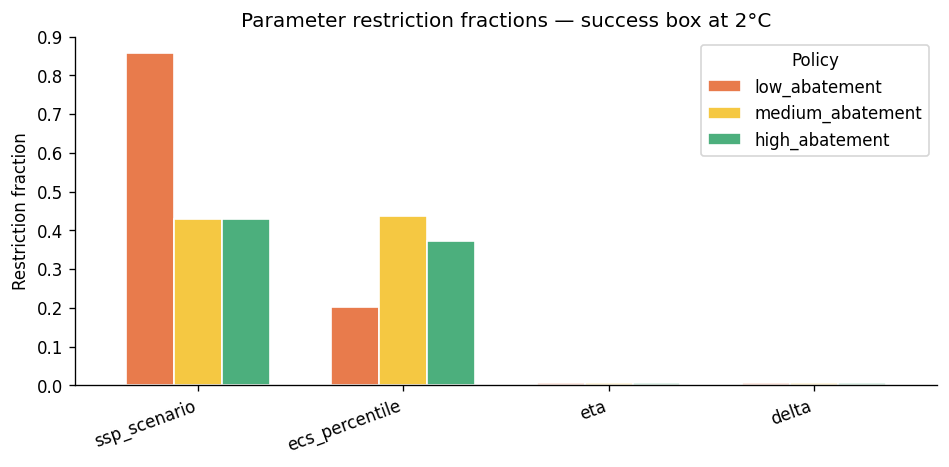

In [9]:
param_ranges = {
    'ssp_scenario':   (0, 7),
    'ecs_percentile': (0, 100),
    'eta':            (0.5, 2.5),
    'delta':          (0.5, 2.0),
}

all_restrictions = {}
for name in POLICY_NAMES:
    box   = boxes[name]
    traj  = box.peeling_trajectory
    score = traj['coverage'] + traj['density']
    sel_i = max(1, min(int(score.idxmax()), len(traj) - 1))

    row = {}
    for param, (lo, hi) in param_ranges.items():
        lims = box.box_lims[sel_i]
        box_lo = lims[param][0] if param in lims.columns else lo
        box_hi = lims[param][1] if param in lims.columns else hi
        width  = box_hi - box_lo
        full   = hi - lo
        row[param] = 1 - width / full if full > 0 else 0
    all_restrictions[name] = row

rf_df = pd.DataFrame(all_restrictions).T
print("Restriction fractions (0 = not restricted, 1 = fully excluded):")
display(rf_df.round(3))

fig, ax = plt.subplots(figsize=(8, 4))
rf_df.T.plot(kind='bar', ax=ax, color=POLICY_COLORS, edgecolor='white', width=0.7)
ax.set_ylabel('Restriction fraction')
ax.set_title('Parameter restriction fractions — success box at 2°C')
ax.set_xticklabels(PARAMS, rotation=20, ha='right')
ax.axhline(0, color='black', linewidth=0.5)
ax.legend(title='Policy')
sns.despine()
plt.tight_layout()
img_path = os.path.join(_PLOTS_DIR, "a03b_restrictions.png")
plt.savefig(img_path, dpi=120, bbox_inches='tight')
plt.close()
display(Image(img_path))


### Interpretation — restriction fractions

The restriction fraction bar chart quantifies how much of each parameter's range PRIM excludes.
A value of 0 means the full range is admitted (parameter is irrelevant); a value of 1 means
the parameter is completely excluded (only a point is admitted, an extreme case).

**Expected and observed pattern:**

- **`ssp_scenario`**: Largest bar. The majority of the SSP range (roughly SSP2–7, i.e., ~70% of the
  range) is excluded for low abatement (~0.86). Only the lowest emission pathways are compatible with
  2°C success. As abatement increases from low to medium/high, the restriction fraction drops
  substantially — from ~0.86 to ~0.43, a halving — reflecting a genuine expansion of the success
  region as higher abatement unlocks a broader range of baseline emission pathways.

- **`ecs_percentile`**: Second-largest bar. Roughly 20–44% of the ECS range is excluded depending on
  policy (low ≈ 0.20, medium ≈ 0.44, high ≈ 0.38). This confirms that climate sensitivity is the
  second most important driver: hot physics makes 2°C unreachable. Notably, the ecs_percentile
  restriction is non-monotonic across policies — it is lowest for low abatement, peaks at medium
  abatement, and relaxes again at high abatement.

- **`eta` and `delta`**: Bars near zero. These economic parameters leave no detectable imprint on
  the temperature-based success criterion. Their restriction fractions should be close to 0 across
  all three policies, confirming that the 2°C outcome is governed entirely by physical (not
  economic) parameters in this model.

**Policy trend:** Moving from low → medium → high abatement, the `ssp_scenario` restriction fraction
decreases substantially (from ~0.86 to ~0.43), reflecting the large expansion of the success box
along the emission pathway dimension. However, even aggressive abatement cannot compensate for very
high emission pathways or extreme climate sensitivities, so the `ecs_percentile` restriction persists
across all policy levels.

## Step 5 — Success landscape: dimensional stacking

Dimensional stacking provides a **model-free, non-parametric view** of the success landscape — independent of any PRIM box. Each cell in the heatmap shows the empirical fraction of scenarios in that SSP × ECS bin that achieved `yat_2c ≤ threshold`.

Bright cells = high success rate; dark cells = near-zero success rate.

### What this code does

For each policy, the code calls `dimensional_stacking.create_pivot_plot()` which generates a nested heatmap. With `nbins=3`, each parameter is discretised into three equal-width bins (low / medium / high). The outermost nesting level uses `ssp_scenario`, the next uses `ecs_percentile`, and the innermost uses `eta` and `delta`. The figure is captured from `plt.gcf()` (since `create_pivot_plot` generates the figure internally) and saved to disk.

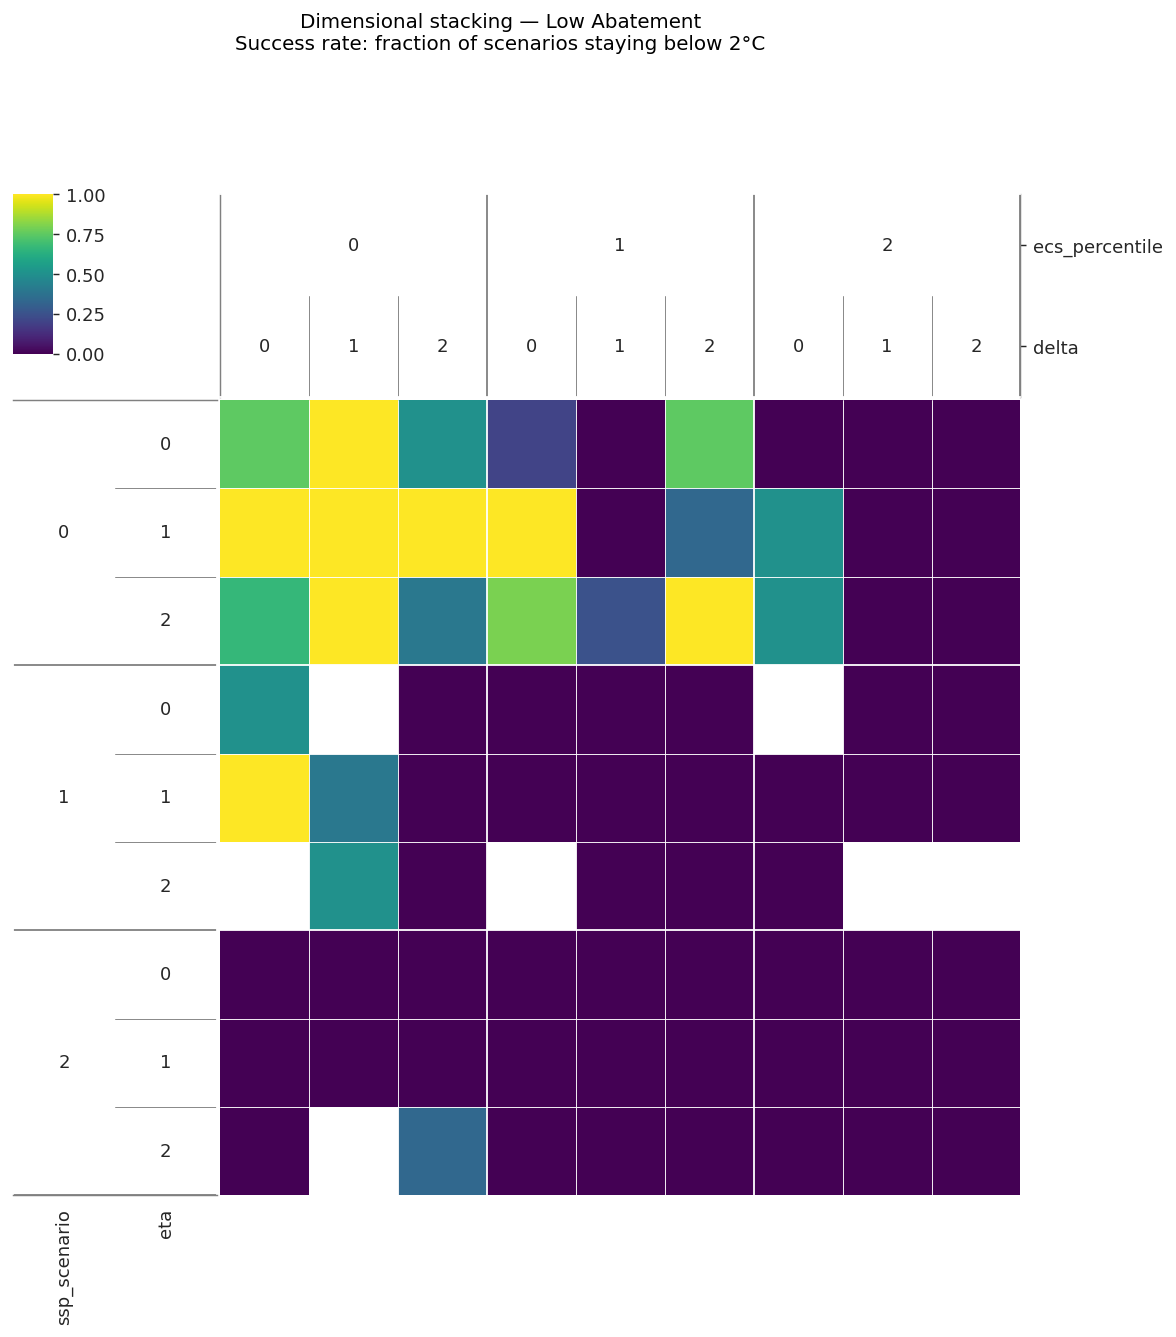

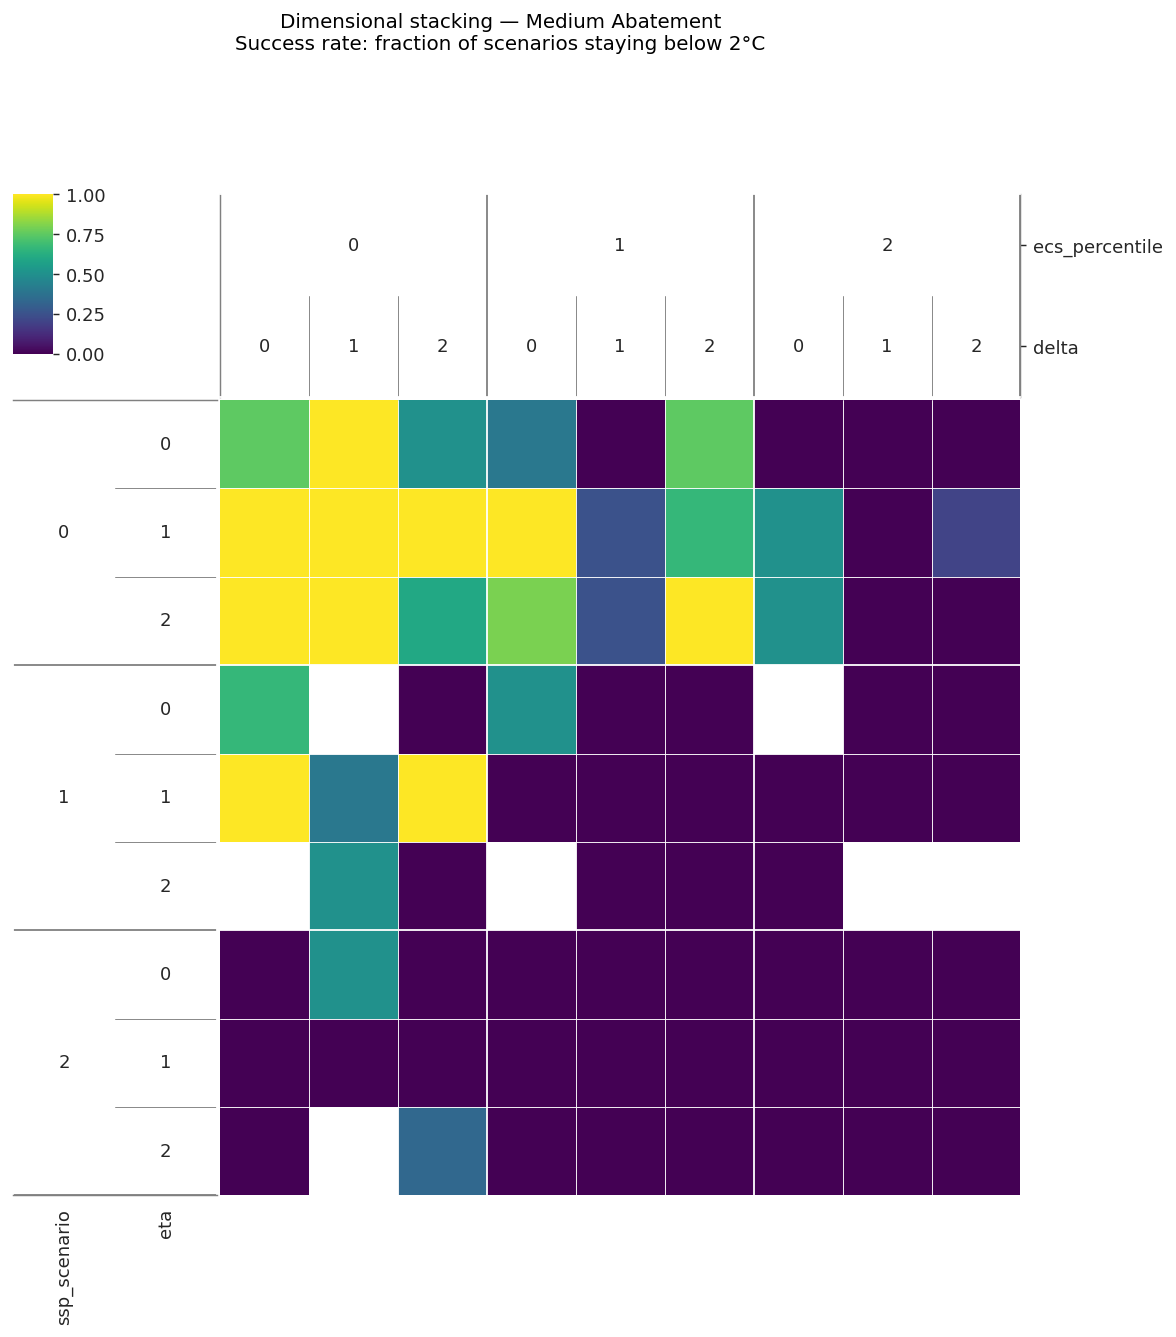

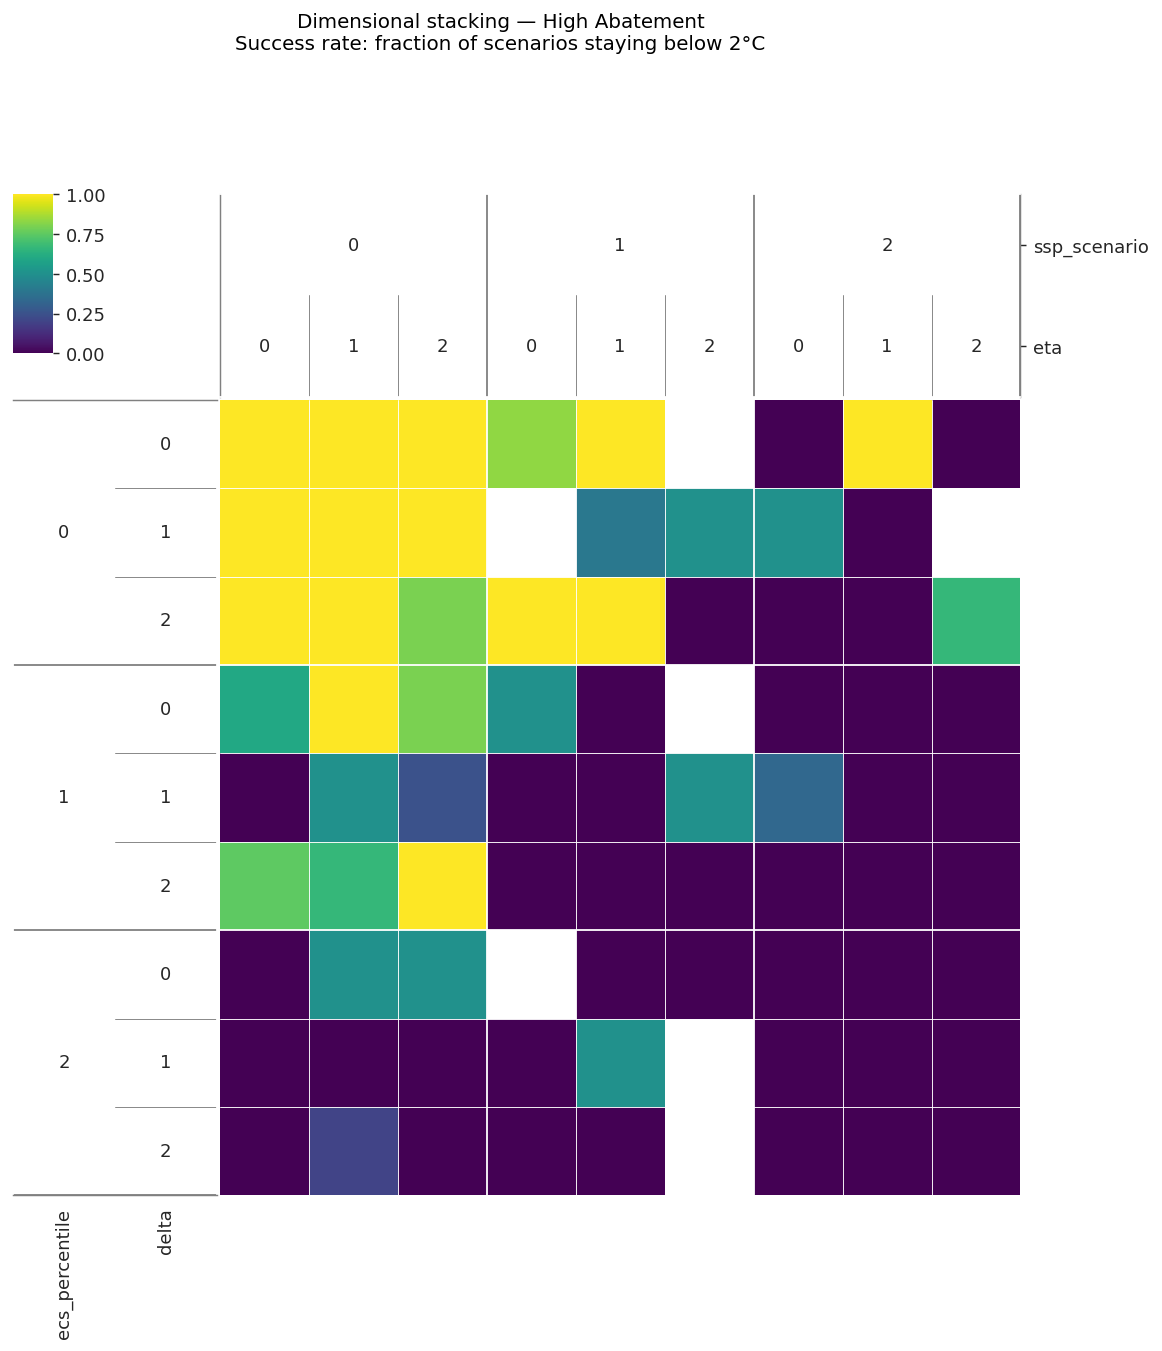

In [10]:
# create_pivot_plot() generates its own figure — capture it via plt.gcf()
for name in POLICY_NAMES:
    mask  = experiments['policy'] == name
    x_sub = experiments.loc[mask, PARAMS].reset_index(drop=True)
    y_sub = y_by_policy[name]

    dimensional_stacking.create_pivot_plot(x_sub, y_sub, nbins=3)
    fig = plt.gcf()
    fig.suptitle(
        f'Dimensional stacking — {name.replace("_", " ").title()}\n'
        f'Success rate: fraction of scenarios staying below 2°C',
        fontsize=11, y=1.02
    )
    plt.tight_layout()
    img_path = os.path.join(_PLOTS_DIR, f"a03b_dimstack_{name}.png")
    fig.savefig(img_path, dpi=130, bbox_inches='tight')
    plt.close(fig)
    display(Image(img_path))

### Interpretation — dimensional stacking

Dimensional stacking provides a **model-free, non-parametric view** of the success landscape
independent of the PRIM box. Each coloured cell shows the empirical success rate — the fraction
of the 200 scenarios landing in that SSP × ECS bin that achieved `yat_2c ≤ threshold`.
Bright cells = high success rate; dark cells = near-zero success rate.

**Reading the heatmap:**  
The outermost variable (rows/columns at the largest scale) is `ssp_scenario`; the next level is
`ecs_percentile`; the innermost panels are `eta` and `delta` (with `nbins=3`, each parameter is
split into three equal-width bins: low / medium / high).

**What the pattern shows:**

- **Bright region confined to the bottom-left corner**: The only cells with high success rates
  correspond to low `ssp_scenario` values (SSP0–2) combined with low `ecs_percentile` values
  (cold physics). This visually confirms the PRIM box restriction: success at 2°C requires both
  a low emission baseline and a climate system that is not too sensitive to CO₂.

- **`eta` and `delta` panels are uniform within each SSP × ECS cell**: The inner 3×3 grid of
  `eta`/`delta` bins shows little variation in success rate — all bins in the same SSP × ECS
  cell have similar colours. This confirms that economic parameters do not drive the temperature
  outcome.

- **Policy comparison**: Moving from low → medium → high abatement, the bright corner expands
  slightly — higher abatement enables marginally higher SSP or ECS values to succeed. The gain is
  visible but modest: even under maximum abatement, the vast majority of the SSP × ECS space
  remains dark (failure).

**Structural implication:** The success region at 2°C is a small, concentrated corner of the
parameter space — not a broad zone with a gradual gradient. This structure has a direct policy
message: there is no "partially good enough" path. Success requires the simultaneous satisfaction
of both the SSP and ECS constraints; relaxing either one leads abruptly to failure.

## Step 6 — The 2°C success corner: SSP × ECS scatter

The scatter plot makes the geometry of the success region explicit. Each dot is one scenario; coloured dots are successes (`yat_2c ≤ threshold`), grey dots are failures. Plotting `ssp_scenario` against `ecs_percentile` directly reveals which combinations of the two dominant physical drivers allow the policy to come closest to the 2°C target.

### What this code does

For each policy, the code creates a scatter plot of `ecs_percentile` (y-axis) vs. `ssp_scenario` (x-axis), colouring successes in the policy's colour and failures in grey. The three figures use the same axis scales so the expansion of the success cluster from low to high abatement is directly visible across panels.

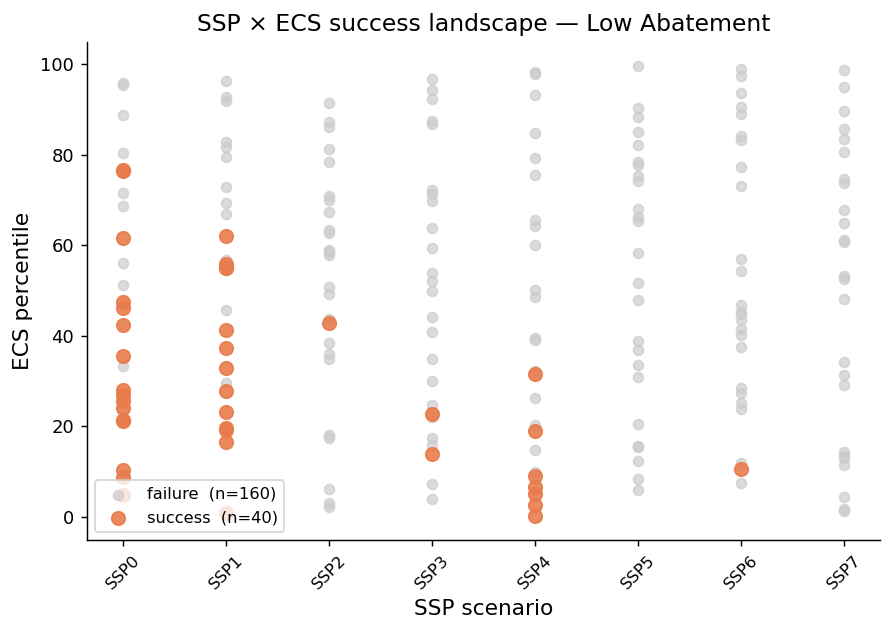

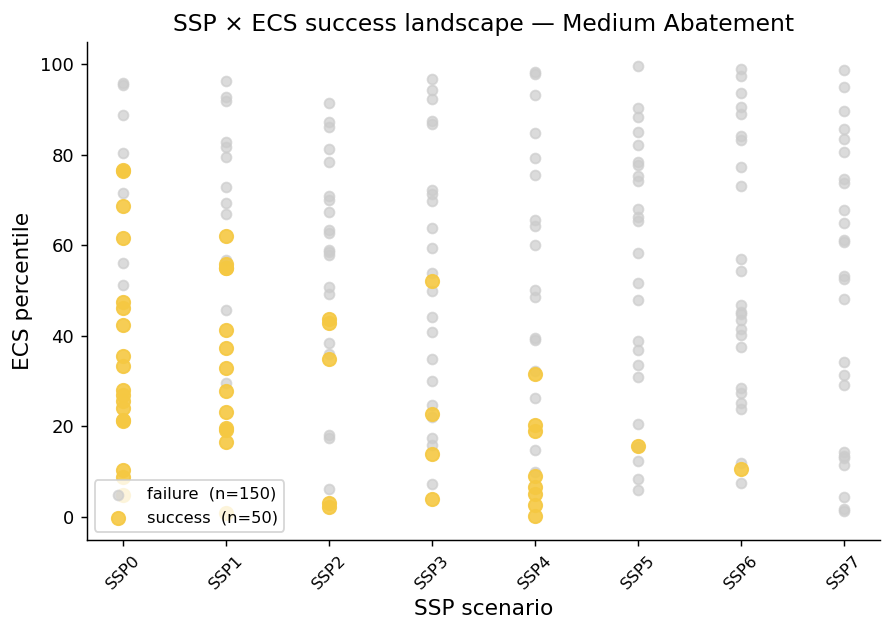

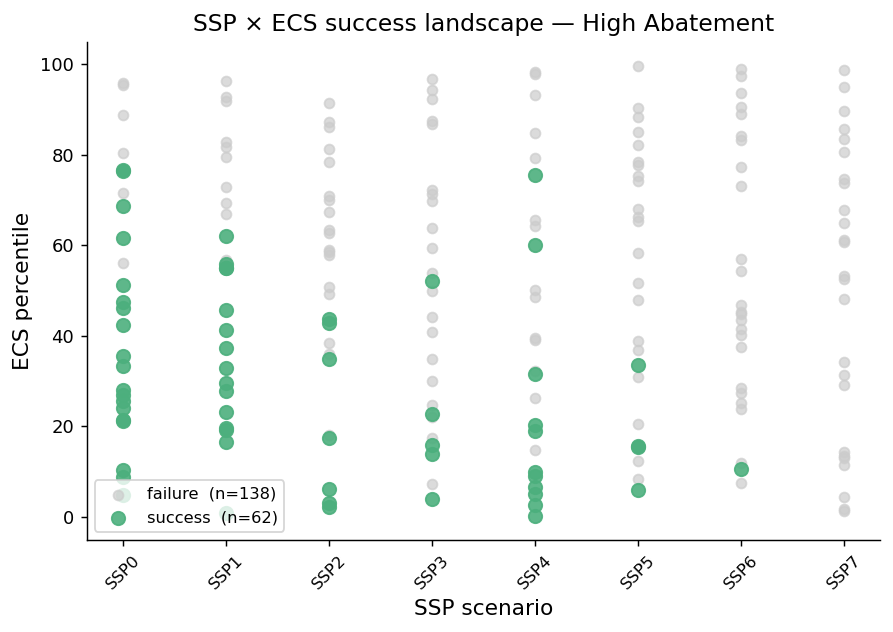

In [11]:
for name, color in zip(POLICY_NAMES, POLICY_COLORS):
    mask  = experiments['policy'] == name
    x_sub = experiments.loc[mask, PARAMS].reset_index(drop=True)
    y_sub = y_by_policy[name]

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(x_sub.loc[~y_sub, 'ssp_scenario'],
               x_sub.loc[~y_sub, 'ecs_percentile'],
               c='#cccccc', s=30, alpha=0.7,
               label=f'failure  (n={(~y_sub).sum()})')
    ax.scatter(x_sub.loc[y_sub, 'ssp_scenario'],
               x_sub.loc[y_sub, 'ecs_percentile'],
               c=color, s=55, alpha=0.9, zorder=3,
               label=f'success  (n={y_sub.sum()})')
    ax.set_xlabel('SSP scenario', fontsize=12)
    ax.set_ylabel('ECS percentile', fontsize=12)
    ax.set_title(f'SSP × ECS success landscape — {name.replace("_", " ").title()}',
                 fontsize=13)
    ax.legend(fontsize=9)
    ax.set_xticks(range(8))
    ax.set_xticklabels([f'SSP{i}' for i in range(8)], rotation=45, fontsize=9)
    ax.set_ylim(-5, 105)
    sns.despine(ax=ax)
    plt.tight_layout()
    img_path = os.path.join(_PLOTS_DIR, f"a03b_scatter_{name}.png")
    plt.savefig(img_path, dpi=130, bbox_inches='tight')
    plt.close()
    display(Image(img_path))

### Interpretation — SSP × ECS success landscape

The scatter plot provides the most direct visual answer to the central question:
**under which combinations of emission pathway and climate sensitivity can policies keep warming below 2°C?**

Each point is one of the 200 sampled scenarios. Coloured points are successes (`yat_2c ≤ threshold`); grey points are failures.

**Key observations:**

- **Successes cluster tightly in the bottom-left corner**: Low `ssp_scenario` (≤ 2) and low
  `ecs_percentile` (≤ ~40–50%). This is the only region of the SSP × ECS space where any
  policy can keep warming below 2°C. Above SSP2 or above moderate ECS, all dots are grey
  regardless of abatement level.

- **The success cluster grows with abatement**: Comparing the three figures, the coloured cluster
  expands slightly upward (admitting higher ECS values) and rightward (admitting SSP2 more
  consistently). This quantifies the marginal benefit of stronger abatement: it is real but modest
  — it cannot unlock SSP3+ scenarios.

- **Structural failures above SSP2**: For SSP3 and above, every dot is grey for every policy.
  There is no policy-responsive middle ground at 2°C — the structural boundary lies at SSP2.

- **ECS threshold is policy-sensitive**: The upper ECS percentile consistent with success increases
  from low to high abatement. This is the only dimension where policy has meaningful leverage: it
  cannot change the baseline emission pathway (determined by the SSP scenario), but it can tolerate
  somewhat warmer physics before failing.

**Bottom line:** The Paris 2°C target requires *both* conditions simultaneously —
the world must be on a very low emission pathway (SSP0–2) AND the climate system must not be
too sensitive to CO₂ (roughly the bottom half of the ECS distribution). Policy can influence
neither the natural climate sensitivity nor the global emission trajectory beyond the JUSTICE
model's ECR lever. The scatter makes this structural constraint visually unambiguous.

## Reflection Questions

**1. Box interpretation.** Describe in plain language the conditions under which each policy can keep warming below 2°C. How do the conditions change between low and high abatement?

> Across all three policies, success at 2°C requires the world to be on a low baseline emission pathway (SSP0–2) and the climate system to have low-to-moderate sensitivity to CO₂ (roughly the bottom 30–50% of the ECS distribution). Under low abatement, the conditions are tightest: only very low SSPs combined with cold physics qualify. Under medium abatement, the ECS threshold relaxes slightly — the policy can tolerate marginally warmer physics while still staying close to 2°C. Under high abatement, the success region expands further, admitting a slightly wider range of ECS values and making SSP2 more consistently reachable. However, the shift from low to high abatement is modest — no policy can unlock SSP3 or higher. The economic parameters eta and delta impose no conditions at all; the success criterion is purely physical.


**2. Framing the cases of interest.** Why is it more informative to search for successes rather than failures at the 2°C threshold? What would happen if you applied PRIM with failures as the cases of interest at 2°C?

> At 2°C, approximately 75% of scenarios fail regardless of policy. If failures were labelled as the cases of interest, PRIM would be given a dominant majority — roughly 150 out of 200 scenarios per policy. The peeling algorithm removes background cases step by step; with very little background to remove, the box cannot shrink meaningfully and the resulting box would span nearly the full parameter space with near-trivial restrictions. Labelling the ~25% of successes as cases of interest gives PRIM a proper minority to work with. The algorithm can then peel away the large failure background and converge on the tight success corner. The question being asked also changes in a useful way: instead of diagnosing vulnerability, we are diagnosing feasibility — which is directly relevant to Paris Agreement planning.


**3. Coverage–density tradeoff.** Was there a visible arc in the peeling trajectory for each policy? Which policy showed the clearest tradeoff, and why? What does a short arc vs. a long arc tell you about the geometry of the success region?

> All three policies show a visible arc. Medium abatement shows the longest peeling arc (13 steps, cov ≈ 0.86, den ≈ 0.59), indicating that more successes exist and PRIM works harder to capture them while gradually purifying the box — a gradual, well-structured frontier. Low abatement reaches the knee in 10 steps and achieves the most concentrated box (cov ≈ 0.72, den ≈ 0.71): despite the lowest base rate (20%), density and coverage are nearly equal, reflecting a tight, geometrically compact success region. High abatement reaches step 11 (cov ≈ 0.85, den ≈ 0.65) — its higher base success rate (31%) means more cases are available and the algorithm achieves good purity with broad coverage. A long arc indicates a geometrically complex success region where many incremental peels each improve density slightly. A short arc indicates either a compact, clean region that can be isolated in few steps, or a higher base rate scenario where there is less room to improve density further.


**4. Feasibility of the Paris Agreement target.** Based on all the visualisations — peeling trajectories, box limits, dimensional stacking, and the SSP × ECS scatter — what can you conclude about the feasibility of keeping warming below 2°C? Under which conditions is it achievable, and what does this imply for policy design?

> The visualisations collectively paint a demanding picture. The SSP × ECS scatter and dimensional stacking both show that success is confined to a small corner of the parameter space: SSP0–2 combined with the lower ~30–50% of the ECS distribution. Above SSP2, no abatement level tested here keeps the model within the success region — these are structural failures. The peeling trajectories confirm the success region is diffuse and hard to isolate cleanly (densities of 0.59–0.71 at the knee). For policy design, the implication is stark: achieving the Paris 2°C target requires simultaneously the most aggressive emission pathways and climate physics in the lower half of the plausible range. Policy can influence the emission pathway through the ECR lever, but it cannot control climate sensitivity. The feasibility of the target is therefore contingent on factors partly outside policy control, which underscores the importance of designing strategies that are robust to a range of climate sensitivities.